In [31]:
import subprocess
import sys

# Désinstaller TOUT ce qui est lié à PIL/Pillow
subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "Pillow", "PIL", "image"])

# Réinstaller Pillow proprement
subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", "Pillow==11.0.0"])

print("✅ Redémarrez le Kernel maintenant (Kernel → Restart Kernel)")

✅ Redémarrez le Kernel maintenant (Kernel → Restart Kernel)


In [32]:
%load_ext autoreload
%autoreload 2

from data_processing import load_and_clean_data, explode_column
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Charger les données
df = load_and_clean_data('netflix_titles.csv')
print(f"✅ Données chargées : {len(df)} lignes, {len(df.columns)} colonnes")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Données chargées : 8807 lignes, 15 colonnes


In [33]:
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,wait_time_years,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,1.0,90.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,0.0,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,0.0,1.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,0.0,1.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,0.0,2.0


In [34]:
display(df.tail())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,wait_time_years,duration_num
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,12.0,158.0
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019.0,1.0,2.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,10.0,88.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,14.0,88.0
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019.0,4.0,111.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8807 non-null   object        
 1   type             8807 non-null   object        
 2   title            8807 non-null   object        
 3   director         6173 non-null   object        
 4   cast             7982 non-null   object        
 5   country          7976 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8807 non-null   int64         
 8   rating           8803 non-null   object        
 9   duration         8804 non-null   object        
 10  listed_in        8807 non-null   object        
 11  description      8807 non-null   object        
 12  year_added       8797 non-null   float64       
 13  wait_time_years  8797 non-null   float64       
 14  duration_num     8804 non-null   float64

In [36]:
print(f"Le dataset contient {df.shape[0]} observations (lignes) et {df.shape[1]} variables (colonnes).")

Le dataset contient 8807 observations (lignes) et 15 variables (colonnes).


In [37]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'wait_time_years', 'duration_num'],
      dtype='object')

In [38]:
df.dtypes

show_id                    object
type                       object
title                      object
director                   object
cast                       object
country                    object
date_added         datetime64[ns]
release_year                int64
rating                     object
duration                   object
listed_in                  object
description                object
year_added                float64
wait_time_years           float64
duration_num              float64
dtype: object

In [39]:
pourcentage_manquants = (df.isnull().sum() / len(df)) * 100
print(pourcentage_manquants[pourcentage_manquants > 0])

director           29.908028
cast                9.367549
country             9.435676
date_added          0.113546
rating              0.045418
duration            0.034064
year_added          0.113546
wait_time_years     0.113546
duration_num        0.034064
dtype: float64


In [40]:
%pip install missingno

In [41]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.show()

AttributeError: module 'PIL' has no attribute 'Image'

AttributeError: module 'PIL' has no attribute 'Image'

<Figure size 2500x1000 with 2 Axes>

In [ ]:
df.sample(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,wait_time_years,duration_num
2360,s2361,Movie,One-Way to Tomorrow,Ozan Açıktan,"Dilan Çiçek Deniz, Metin Akdülger",Turkey,2020-06-19,2020,TV-MA,90 min,"Dramas, International Movies, Romantic Movies",Two strangers cross paths on a train en route ...,2020.0,0.0,90.0


In [ ]:
df[df['title'] == 'Catch Me If You Can']

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,wait_time_years,duration_num
329,s330,Movie,Catch Me If You Can,Steven Spielberg,"Leonardo DiCaprio, Tom Hanks, Christopher Walk...","United States, Canada",2021-08-01,2002,PG-13,142 min,Dramas,An FBI agent makes it his mission to put cunni...,2021.0,19.0,142.0


In [ ]:
# Film le plus récent (basé sur l'année de sortie)
film_recent = df[df['type'] == 'Movie'].sort_values('release_year', ascending=False).head(1)
print("Film le plus récent :", film_recent['title'].values[0])

# Série la plus récente
serie_recente = df[df['type'] == 'TV Show'].sort_values('release_year', ascending=False).head(1)
print("Série la plus récente :", serie_recente['title'].values[0])

Film le plus récent : My Heroes Were Cowboys
Série la plus récente : Metal Shop Masters


In [ ]:
# Film le plus ancien
df['date_added'].dtype

dtype('<M8[ns]')

In [ ]:
# Extrait uniquement les suites de chiffres (\d+) de la colonne texte
df['duration'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Vérification
display(df[['type', 'duration']].head())

,type,duration
0,Movie,90.0
1,TV Show,2.0
2,TV Show,1.0
3,TV Show,1.0
4,TV Show,2.0


In [42]:
df['listed_in_list'] = df['listed_in'].str.split(', ')
print("Exemple de conversion :")
print(df['listed_in_list'].head(5))

Exemple de conversion :
0                                      [Documentaries]
1    [International TV Shows, TV Dramas, TV Mysteries]
2    [Crime TV Shows, International TV Shows, TV Ac...
3                             [Docuseries, Reality TV]
4    [International TV Shows, Romantic TV Shows, TV...
Name: listed_in_list, dtype: object


In [43]:
print(f"Valeurs uniques - Type : {df['type'].nunique()}")
print(df['type'].unique())
print(f"\nValeurs uniques - Rating : {df['rating'].nunique()}")
print(df['rating'].unique()[:10])
print(f"\nValeurs uniques - Release Year : {df['release_year'].nunique()}")
print(f"Années : {sorted(df['release_year'].unique())[:10]}...")

Valeurs uniques - Type : 2
['Movie' 'TV Show']

Valeurs uniques - Rating : 17
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G']

Valeurs uniques - Release Year : 74
Années : [np.int64(1925), np.int64(1942), np.int64(1943), np.int64(1944), np.int64(1945), np.int64(1946), np.int64(1947), np.int64(1954), np.int64(1955), np.int64(1956)]...


In [ ]:
for col in ['type', 'country', 'release_year', 'rating']:
    print(f"--- Valeurs uniques pour {col} ---")
    print(df[col].dropna().unique()[:10]) # On limite à 10 pour ne pas inonder l'écran
    print("\n")

--- Valeurs uniques pour type ---
['Movie' 'TV Show']


--- Valeurs uniques pour country ---
['United States' 'South Africa' 'India'
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia'
 'United Kingdom' 'Germany, Czech Republic' 'Mexico' 'Turkey' 'Australia'
 'United States, India, France']


--- Valeurs uniques pour release_year ---
[2020 2021 1993 2018 1996 1998 1997 2010 2013 2017]


--- Valeurs uniques pour rating ---
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G']




## 20. Réalisateurs ayant produit plus d'une œuvre

In [45]:
directors_count = df['director'].dropna().str.split(', ').explode().value_counts()
multi_directors = directors_count[directors_count > 1].head(10)
print("Top 10 réalisateurs avec plusieurs œuvres :")
print(multi_directors)

Top 10 réalisateurs avec plusieurs œuvres :
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64


## 21 & 22. Années avec le plus d'ajouts

In [ ]:
movies_per_year = df[df['type'] == 'Movie'].groupby('year_added').size()
shows_per_year = df[df['type'] == 'TV Show'].groupby('year_added').size()

print(f"Année avec le plus de films : {movies_per_year.idxmax()} ({int(movies_per_year.max())} films)")
print(f"Année avec le plus de séries : {shows_per_year.idxmax()} ({int(shows_per_year.max())} séries)")

Année avec le plus de films : 2019.0 (1424 films)
Année avec le plus de séries : 2020.0 (595 séries)


: 

In [ ]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


a. Répartition du type d'œuvres
a_repartition_type.png enregistré


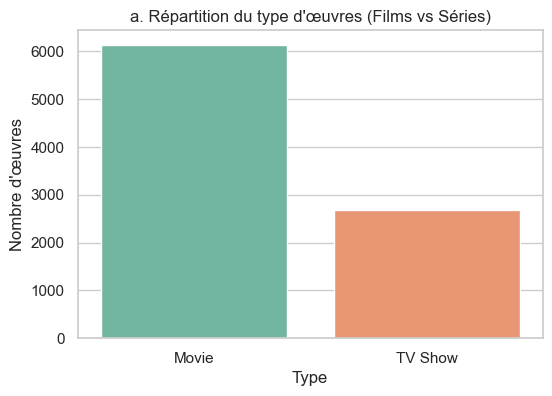

b. Répartition des pays producteurs
b_top_pays.png enregistré


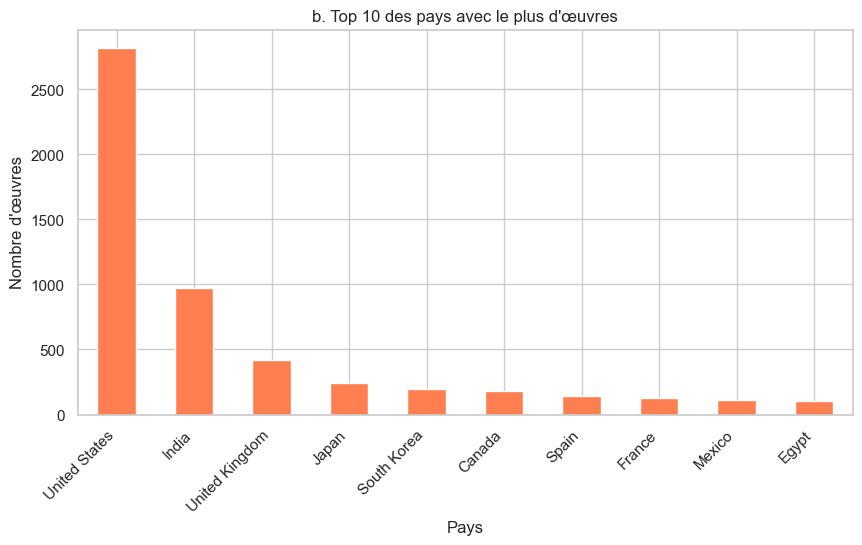

c. Répartition des années (année d'ajout au catalogue)
c_repartition_annees.png enregistré


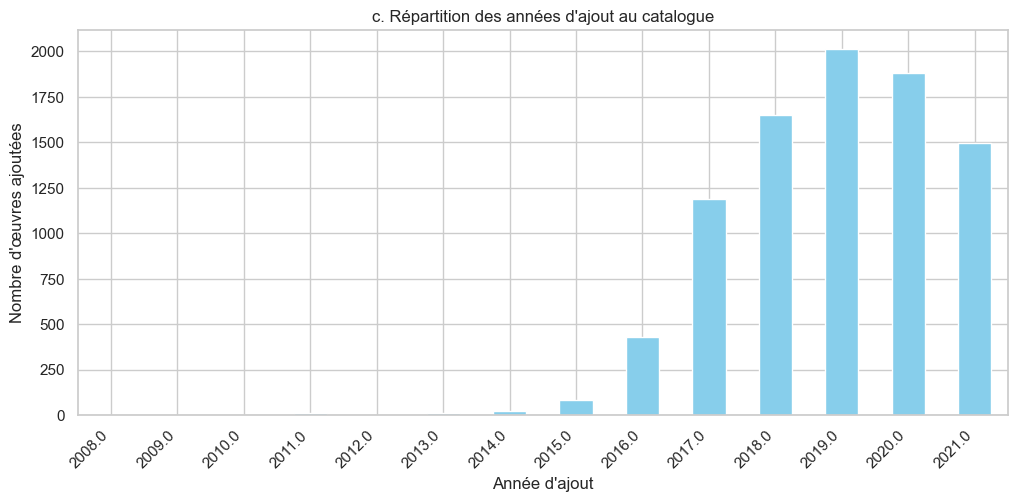

d. Répartition des ratings
d_repartition_ratings.png enregistré


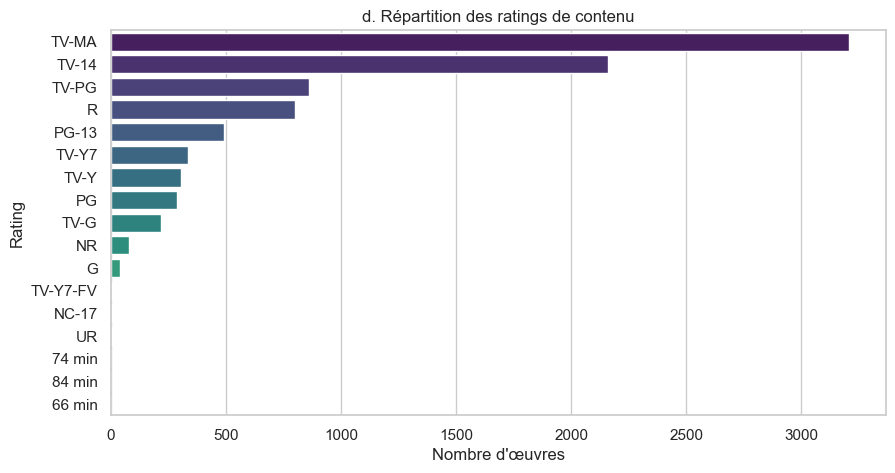

e. Répartition de la durée des films
e_repartition_duree_films.png enregistré


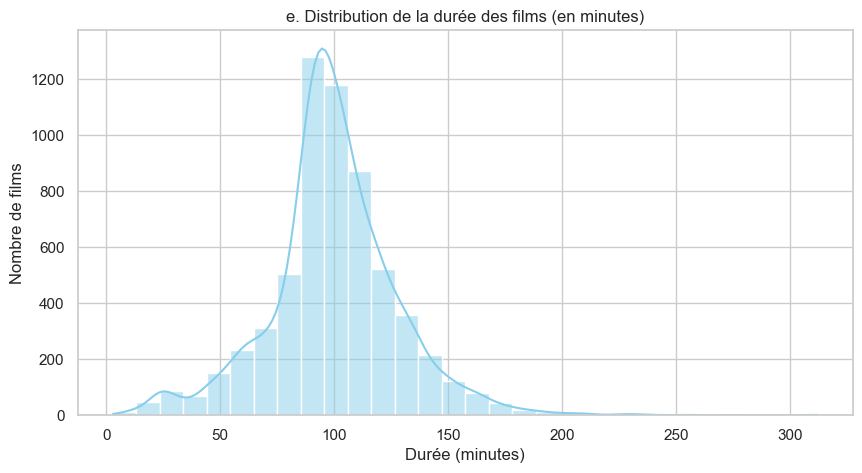

f. Répartition du nombre de saisons des séries
f_repartition_duree_series.png enregistré


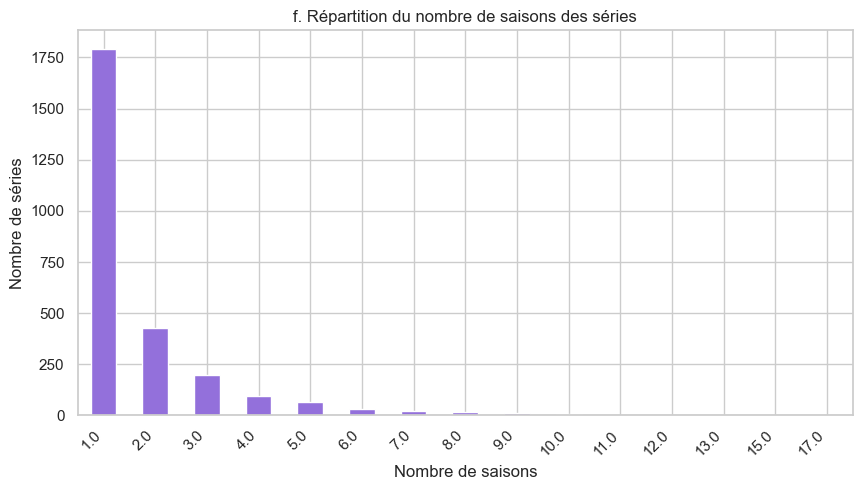

g. Répartition des genres
g_repartition_genres.png enregistré


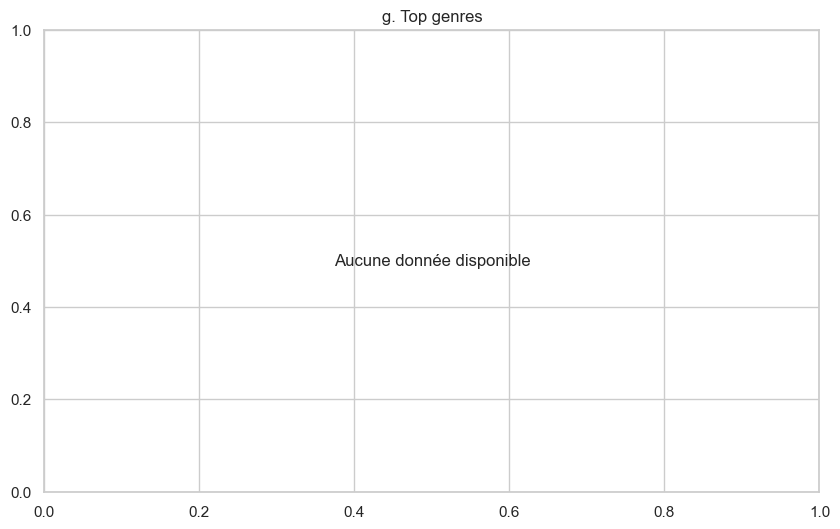

h. Top 5 des séries les plus longues
h_top_5_series.png enregistré


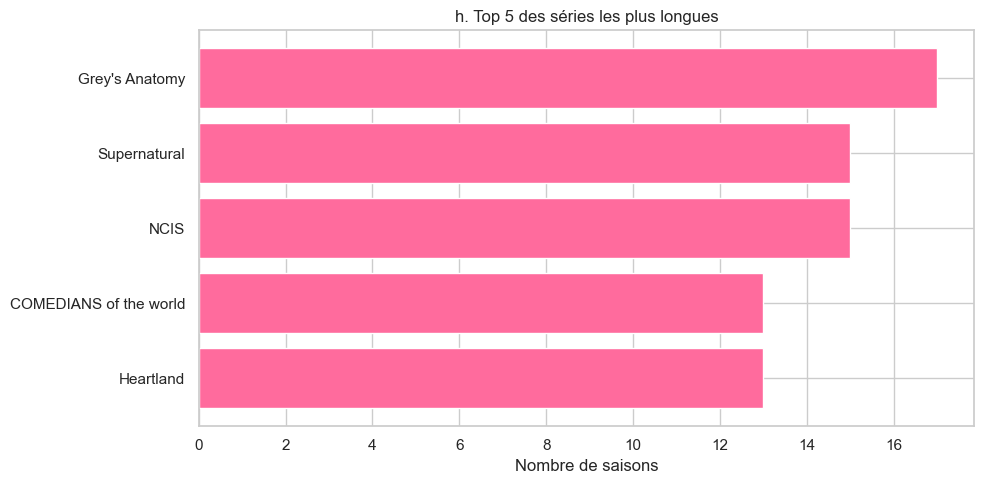

i. Top 5 des films les plus longs
i_top_5_films.png enregistré


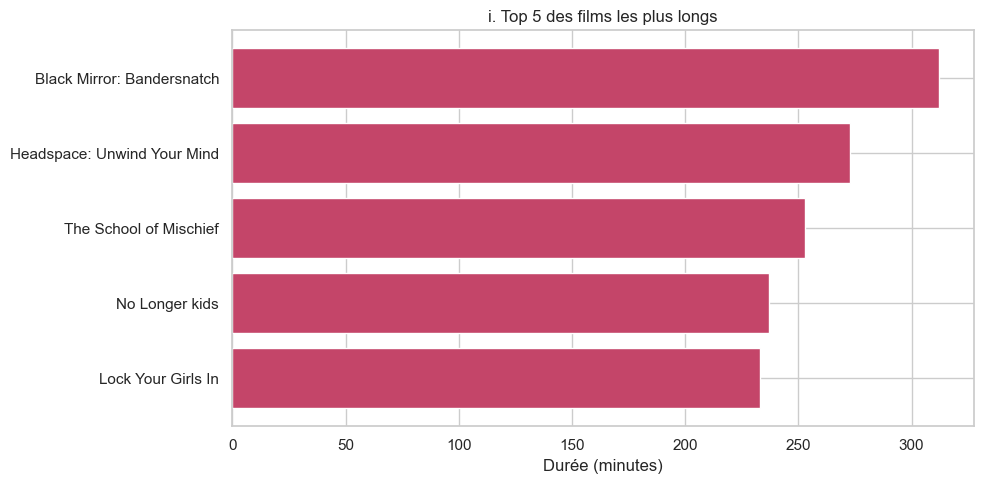

j. Répartition des directors français
j_directors_francais.png enregistré


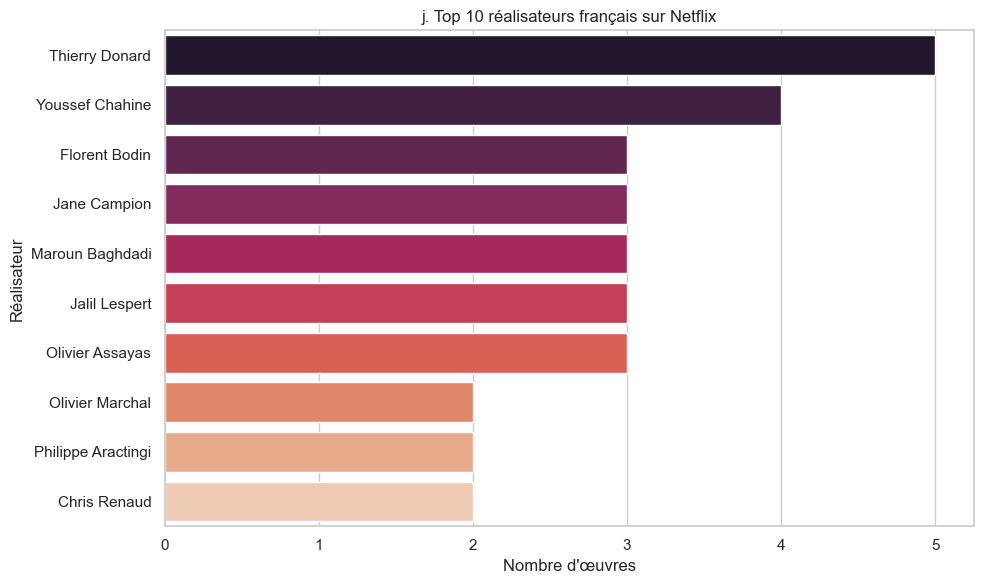

k. Répartition des œuvres par date d'ajout
k_evolution_ajouts.png enregistré


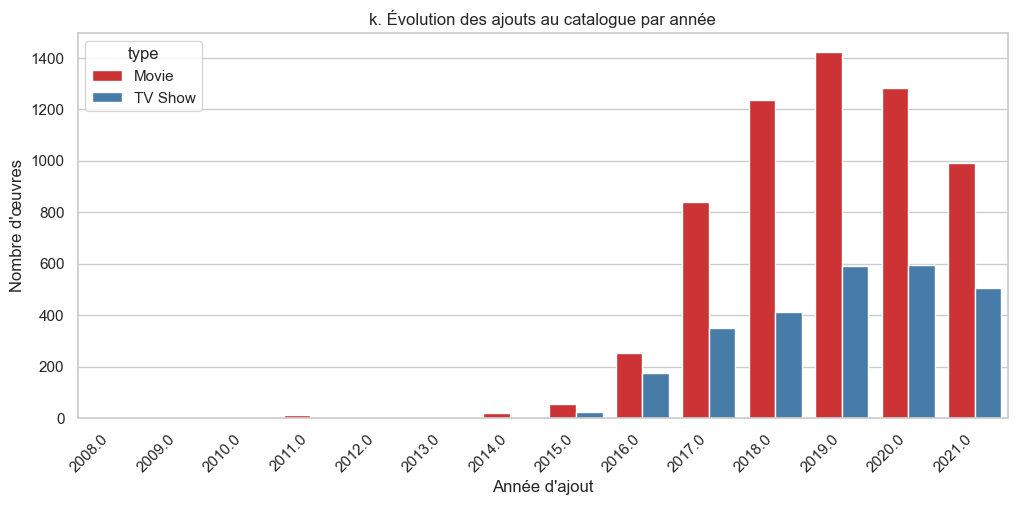

l. Bonus : Répartition des années de sortie (release_year)
l_repartition_release_year.png enregistré


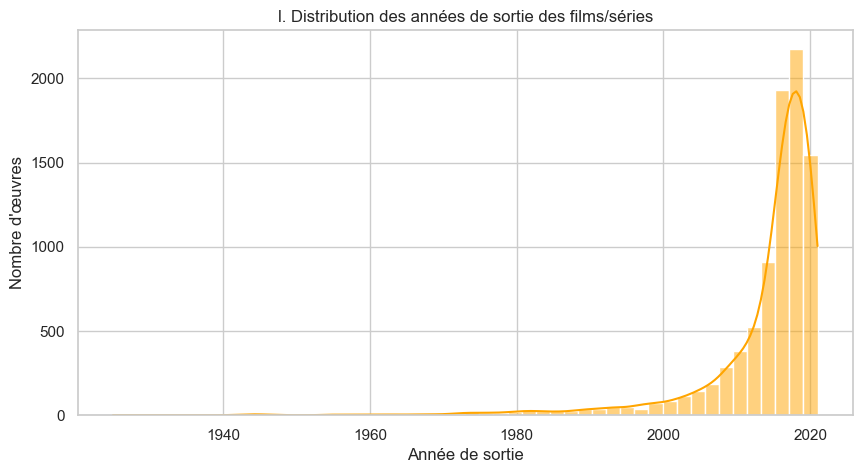

In [ ]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Configurer le style visuel
sns.set_theme(style="whitegrid")

# Fonction utilitaire pour afficher et sauvegarder sans doublons
def save_and_show_fig(filename):
    filepath = f'Assets/Images/{filename}'
    
    # Sauvegarder seulement s'il n'existe pas
    if not os.path.exists(filepath):
        plt.savefig(filepath, bbox_inches='tight', dpi=100)
        print(f"{filename} enregistré")
    else:
        print(f"{filename} existe déjà")
    
    # TOUJOURS afficher
    plt.show()

print("a. Répartition du type d'œuvres")
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)
plt.title("a. Répartition du type d'œuvres (Films vs Séries)")
plt.xlabel("Type")
plt.ylabel("Nombre d'œuvres")
save_and_show_fig('a_repartition_type.png')

print("b. Répartition des pays producteurs")
plt.figure(figsize=(10, 5))
df['country'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title("b. Top 10 des pays avec le plus d'œuvres")
plt.ylabel("Nombre d'œuvres")
plt.xlabel("Pays")
plt.xticks(rotation=45, ha='right')
save_and_show_fig('b_top_pays.png')

print("c. Répartition des années (année d'ajout au catalogue)")
plt.figure(figsize=(12, 5))
df['year_added'].dropna().value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("c. Répartition des années d'ajout au catalogue")
plt.xlabel("Année d'ajout")
plt.ylabel("Nombre d'œuvres ajoutées")
plt.xticks(rotation=45, ha='right')
save_and_show_fig('c_repartition_annees.png')

print("d. Répartition des ratings")
plt.figure(figsize=(10, 5))
df_ratings = df.dropna(subset=['rating'])['rating'].value_counts()
sns.barplot(y=df_ratings.index, x=df_ratings.values, hue=df_ratings.index, palette='viridis', legend=False)
plt.title("d. Répartition des ratings de contenu")
plt.xlabel("Nombre d'œuvres")
plt.ylabel("Rating")
save_and_show_fig('d_repartition_ratings.png')

print("e. Répartition de la durée des films")
plt.figure(figsize=(10, 5))
sns.histplot(df[df['type'] == 'Movie']['duration_num'], bins=30, kde=True, color='skyblue')
plt.title("e. Distribution de la durée des films (en minutes)")
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de films")
save_and_show_fig('e_repartition_duree_films.png')

print("f. Répartition du nombre de saisons des séries")
plt.figure(figsize=(10, 5))
df_tv = df[df['type'] == 'TV Show'].copy()
df_tv['duration_num'].value_counts().sort_index().plot(kind='bar', color='mediumpurple')
plt.title("f. Répartition du nombre de saisons des séries")
plt.xlabel("Nombre de saisons")
plt.ylabel("Nombre de séries")
plt.xticks(rotation=45, ha='right')
save_and_show_fig('f_repartition_duree_series.png')

print("g. Répartition des genres")
df_genres = explode_column(df, 'listed_in', 'genre')
top_genres = df_genres['genre'].value_counts().head(10)

plt.figure(figsize=(10, 6))
if len(top_genres) > 0:
    sns.barplot(y=top_genres.index, x=top_genres.values, hue=top_genres.index, palette='husl', legend=False)
    plt.xlabel("Nombre d'œuvres")
    plt.ylabel("Genre")
    plt.title("g. Top 10 des genres les plus représentés")
else:
    plt.text(0.5, 0.5, 'Aucune donnée disponible', ha='center', va='center')
    plt.title("g. Top genres")
save_and_show_fig('g_repartition_genres.png')

print("h. Top 5 des séries les plus longues")
df_tv_shows = df[df['type'] == 'TV Show'].copy()
top_5_shows = df_tv_shows.nlargest(5, 'duration_num')[['title', 'duration_num']].sort_values('duration_num')

plt.figure(figsize=(10, 5))
plt.barh(top_5_shows['title'], top_5_shows['duration_num'], color='#FF6B9D')
plt.xlabel("Nombre de saisons")
plt.title("h. Top 5 des séries les plus longues")
plt.tight_layout()
save_and_show_fig('h_top_5_series.png')

print("i. Top 5 des films les plus longs")
df_movies = df[df['type'] == 'Movie'].copy()
top_5_movies = df_movies.nlargest(5, 'duration_num')[['title', 'duration_num']].sort_values('duration_num')

plt.figure(figsize=(10, 5))
plt.barh(top_5_movies['title'], top_5_movies['duration_num'], color='#C44569')
plt.xlabel("Durée (minutes)")
plt.title("i. Top 5 des films les plus longs")
plt.tight_layout()
save_and_show_fig('i_top_5_films.png')

print("j. Répartition des directors français")
df_french = df[df['country'].str.contains('France', na=False, case=False)].copy()
df_french_directors = df_french.dropna(subset=['director']).copy()
df_french_directors['director'] = df_french_directors['director'].str.split(', ')
df_french_directors = df_french_directors.explode('director')

top_french_directors = df_french_directors['director'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=top_french_directors.index, x=top_french_directors.values, hue=top_french_directors.index, palette='rocket', legend=False)
plt.xlabel("Nombre d'œuvres")
plt.ylabel("Réalisateur")
plt.title("j. Top 10 réalisateurs français sur Netflix")
plt.tight_layout()
save_and_show_fig('j_directors_francais.png')

print("k. Répartition des œuvres par date d'ajout")
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='year_added', hue='type', palette='Set1')
plt.title("k. Évolution des ajouts au catalogue par année")
plt.xlabel("Année d'ajout")
plt.ylabel("Nombre d'œuvres")
plt.xticks(rotation=45, ha='right')
save_and_show_fig('k_evolution_ajouts.png')

print("l. Bonus : Répartition des années de sortie (release_year)")
plt.figure(figsize=(10, 5))
sns.histplot(df, x='release_year', bins=50, kde=True, color='#FFA500')
plt.title("l. Distribution des années de sortie des films/séries")
plt.xlabel("Année de sortie")
plt.ylabel("Nombre d'œuvres")
save_and_show_fig('l_repartition_release_year.png')

# 🎬 Mon Analyse des données Netflix

Suite à la création de mes graphiques, voici mes **conclusions principales** :

- Netflix propose beaucoup plus de *Films* que de *Séries*.
- Le pays qui produit le plus de contenu est les **États-Unis**.
- Il y a eu une énorme augmentation des ajouts sur la plateforme à partir de 2018.

C'était mon premier Notebook Jupyter !

## Bonus : Analyse approfondie des genres (Feature Engineering)

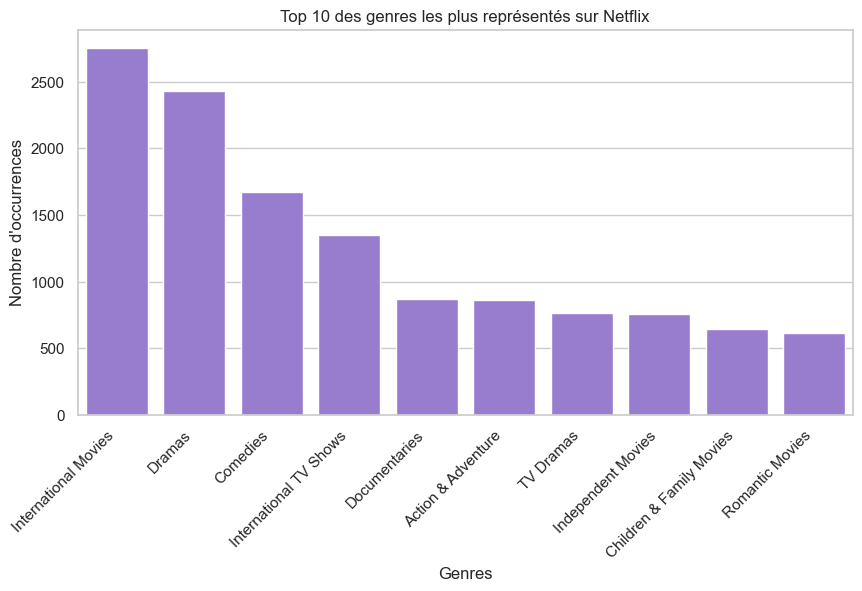

In [ ]:
# 0. Chargement de la donnée isolée
df_bonus = load_and_clean_data('netflix_titles.csv')

# 1. Séparation des genres
df_genres = explode_column(df_bonus, 'listed_in', 'genre')

# 2. Comptage
top_genres = df_genres['genre'].value_counts().head(10)

# 3. Affichage robuste avec Seaborn
plt.figure(figsize=(10, 5))
# On utilise sns.barplot au lieu de top_genres.plot()
sns.barplot(x=top_genres.index, y=top_genres.values, color='mediumpurple')

plt.title("Top 10 des genres les plus représentés sur Netflix")
plt.ylabel("Nombre d'occurrences")
plt.xlabel("Genres")
plt.xticks(rotation=45, ha='right')

# Enregistrer la figure avant de l'afficher
plt.savefig('top_genres.png', bbox_inches='tight')

plt.show()

In [ ]:
import plotly.express as px

# 1. Préparation des données
df_trend = df_bonus.groupby(['year_added', 'type']).size().reset_index(name='count')

# 2. Création du graphique interactif
fig = px.line(
    df_trend, 
    x='year_added', 
    y='count', 
    color='type',
    # On utilise <br> pour couper le titre, et <sup> pour écrire le sous-titre plus petit
    title="Évolution des ajouts sur Netflix<br><sup>Comparaison entre les Films et les Séries</sup>",
    labels={'year_added': "Année d'ajout", 'count': "Nombre d'œuvres", 'type': "Catégorie"},
    markers=True,
    color_discrete_map={'Movie': '#B1060F', 'TV Show': '#000000'}
)

# 3. Affichage
fig.show()